In [77]:
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from scipy.signal.windows import tukey
import jax
import jax.numpy as jnp
from astropy.time import Time
from ripple.waveforms import IMRPhenomD, IMRPhenomXAS
from jimgw.single_event.detector import H1, L1
from functools import partial
import sys
sys.path.append('../../mist-base/GW')
sys.path.append('../../')

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

pf.housestyle_rcparams()

True

In [ ]:
defaults = {
    "approximant": "IMRPhenomD",
    "f_min": 20., #40.0,
    "f_max": 1024., #400.0,
    "f_ref": 20.0,
    "notches": [60.0, 120.0, 180.0],
    "notch_width": 0.1,
    "trigger_time": 1126259462.4,
    "pre_trigger_time": 2.0,
    "post_trigger_time": 2.0,
    "data_window": 1000,
    "psd_window":4,
    # "psd_pad": 16.0,
    "ifo": "H1",
    # "tukey_alpha": 0.2,
    "posterior_samples_path": "GW150814_posterior_samples.npz",
}

class Base_GW1501914:
    def __init__(self, settings:dict={}, stoch_mu=True):
        self.settings = settings
        self.stoch = stoch_mu
        self._unpack_settings()
        self._initialise_gw()
        self._load_posterior_samples()
        self._setup_waveform()

    ### METHODS ###
    
    def _unpack_settings(self):
        self.approximant = self.settings.get("approximant", "IMRPhenomD")
        self.f_min = self.settings.get("f_min", 20.)
        self.f_max = self.settings.get("f_max", 1024.)
        self.f_ref = self.settings.get("f_ref", 20.0)
        self.notches = self.settings.get("notches", [60.0, 120.0, 180.0])
        self.notch_width = self.settings.get("notch_width", 0.1)
        self.trigger_time = self.settings.get("trigger_time", 1126259462.4)
        self.pre_trigger_time = self.settings.get("pre_trigger_time", 2.0)
        self.post_trigger_time = self.settings.get("post_trigger_time", 2.0)
        self.data_window = self.settings.get("data_window", 1000)
        self.psd_window = self.settings.get("psd_window", 2)
        # self.psd_pad = self.settings.get("psd_pad", 16.0)
        self.ifo = self.settings.get("ifo", "H1")
        # self.tukey_alpha = self.settings.get("tukey_alpha", 0.2) #### CHANGE THIS ####
        self.posterior_samples_path = self.settings.get(
            "posterior_samples_path", "../../mist-base/GW/GW150814_posterior_samples.npz"
        )
        self.key = jax.random.PRNGKey(42)

    def _initialise_gw(self):
        self.event_time = event_gps('GW150914')
        print(f'Fetching {self.data_window}s of data from {self.ifo}. Will take <4mins.')
        self.gwosc_data = TimeSeries.fetch_open_data(self.ifo, self.event_time-2*self.data_window, 
                                                     self.event_time-self.data_window, sample_rate=4096)
        print(f'Calculating PSD for FFT window length {self.psd_window}s.')
        self.psd = self.gwosc_data.psd(fftlength=self.psd_window)
        self.frequencies = self.psd.frequencies.value
        self.tukey_alpha = 1/self.psd_window

        self.times = self.gwosc_data.times.value - self.trigger_time
        self.duration = self.gwosc_data.duration.value
        self.npts = len(self.gwosc_data)
        self.delta_t = self.gwosc_data.dt.value
        self.epoch = self.duration - self.post_trigger_time
        self.gmst = (
            Time(self.trigger_time, format="gps")
            .sidereal_time("apparent", "greenwich")
            .rad
        )
        if self.ifo == "H1":
            self.detector = H1
        elif self.ifo == "L1":
            self.detector = L1
        
    def _tukey(self, x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        window = tukey(np.shape(x)[1], alpha=self.tukey_alpha) # shape [nbins]
        return x*np.expand_dims(window,axis=0) # shape [nsamples, nbins]
    
    def whiten(self, x):
        # x is supplied in form [nbins (complex)]
        x = np.array(x)
        return np.abs(x/np.sqrt(self.psd.data))
    
    def whiten_batch(self,x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        prefactor = np.expand_dims(np.sqrt(np.array(self.psd.data)), axis=0)
        return np.abs(x/prefactor)
         
    
    def _load_posterior_samples(self):
        # print(f"Loading posterior samples from {self.posterior_samples_path}")
        self.posterior_samples = np.load(self.posterior_samples_path)
        self.parameter_names = [
            "M_c",
            "q",
            "s1_z",
            "s2_z",
            "d_L",
            "t_c",
            "phase_c",
            "iota",
            "ra",
            "dec",
            "psi",
        ]
        for param_name in self.posterior_samples.files:
            if param_name not in self.parameter_names:
                raise ValueError(
                    f"Parameter {param_name} not recognized in posterior file"
                )
        self.posterior_array = np.vstack(
            [self.posterior_samples[name] for name in self.parameter_names]
        ).T
        self.posterior_array[:, 1] = (self.posterior_array[:, 1]) / (
            1.0 + self.posterior_array[:, 1]
        ) ** 2  # q -> eta = q / (1 + q)^2
        self.posterior_array[:, 5] = (
            self.epoch + self.posterior_array[:, 5]
        )  # t_c -> t_c + epoch

    def _setup_waveform(self):
        if self.approximant == "IMRPhenomD":
            self.waveform = IMRPhenomD.gen_IMRPhenomD_hphc
        elif self.approximant == "IMRPhenomXAS":
            self.waveform = IMRPhenomXAS.gen_IMRPhenomXAS_hphc
        else:
            raise ValueError(f"Approximant {self.approximant} not recognized")
    
    ### DATA GETTERS ###

    def _get_noise_td(self, nsamples):
        ref = self.event_time-1.5*self.data_window
        nbins = len(self.gwosc_data.crop(ref-self.psd_window/2, ref+self.psd_window/2))
        alldata_raw = jnp.array(self.gwosc_data)
        max_start_index = alldata_raw.shape[0] - nbins
        start_indices = jax.random.randint(self.key, shape=(nsamples,), minval=0, maxval=max_start_index + 1)
        offsets = jnp.arange(nbins)
        indices = start_indices[:, None] + offsets
        return alldata_raw[indices]
    
    def get_noise_fd(self, nsamples):
        noise_td = self._get_noise_td(nsamples=nsamples)
        noise_td_windowed = self._tukey(noise_td)
        noise_fd_complex = jnp.fft.rfft(noise_td_windowed)*self.gwosc_data.dt
        return self.whiten_batch(noise_fd_complex)
    
    def get_GW150914_td(self):
        return TimeSeries.fetch_open_data(self.ifo, self.event_time-self.psd_window/2, 
                                                     self.event_time+self.psd_window/2, sample_rate=4096)
        
    def get_GW150914_fd(self):
        raw = self.get_GW150914_td().data
        raw_windowed = np.squeeze(self._tukey(np.expand_dims(raw,axis=0)), axis=0)
        raw_fd = np.fft.rfft(raw_windowed)*self.gwosc_data.dt
        return self.whiten(raw_fd)
        # return np.abs(raw_fd/np.sqrt(self.psd.data))
    
    ### WAVEFORM GENERATORS ###

    @partial(jax.jit, static_argnums=(0,))
    def call_waveform(self, theta_ripple):
        hp, hc = self.waveform(self.frequencies, theta_ripple, f_ref=self.f_ref)
        return hp, hc
    
    def _fd_theta_batched(self,nsims):
        if not self.stoch:
            choices = np.random.choice(self.posterior_array.shape[0], size=1, replace=True)
            single_param_set = self.posterior_array[choices]
            params_batch = np.tile(single_param_set, (nsims, 1))
            return torch.from_numpy(params_batch)
        else:
            choices = np.random.choice(self.posterior_array.shape[0], size=nsims, replace=True)
            params_batch = self.posterior_array[choices]
            return torch.from_numpy(params_batch)
        
    def _fd_waveform_batched(self, params_batch_tensor):
        params_batch = params_batch_tensor.numpy()
        theta_ripple_batch = params_batch[:, :8]
        ra_batch, dec_batch, psi_batch = params_batch[:, 8], params_batch[:, 9], params_batch[:, 10]
        batched_waveform = jax.vmap(self.call_waveform)
        batched_detector_response = jax.vmap(
            self.detector.fd_response,
            in_axes=(None, {'p': 0, 'c': 0}, {'ra': 0, 'dec': 0, 'psi': 0, 'gmst': None})
        )
        hp_batch, hc_batch = batched_waveform(theta_ripple_batch)
        wf_fd_batch = batched_detector_response(
            self.frequencies,
            {"p": hp_batch, "c": hc_batch},
            {"ra": ra_batch, "dec": dec_batch, "psi": psi_batch, "gmst": self.gmst},
        )
        return self.whiten_batch(wf_fd_batch)


In [97]:
gw = Base_GW1501914()

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 2s.


True

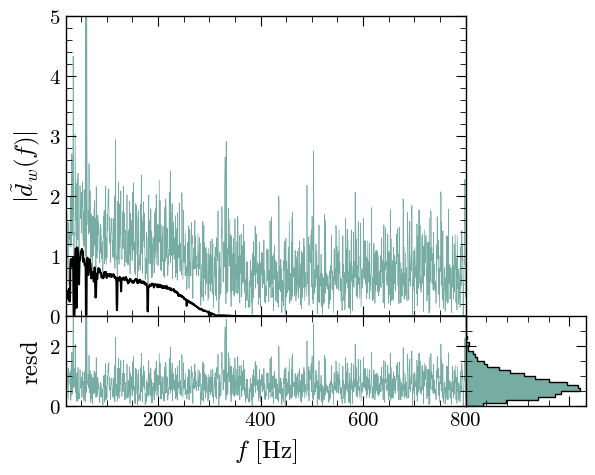

In [104]:
noise = gw.get_noise_fd(4)[0]
theta = gw._fd_theta_batched(4)
mu = gw._fd_waveform_batched(theta)[0]
f = gw.frequencies

fig, ax = pf.create_plot()
plt.setp(ax.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,.3), sharex=ax)
ax3 = fig.add_axes((1,-.3,.3,.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
axes = [ax,ax2,ax3]

ax.plot(f, noise+mu, color='#77aca2', lw=0.5)
ax.plot(f,mu, color='k')

ax2.plot(f, noise, color='#77aca2', lw=0.5)

ax3.hist(noise,bins=np.linspace(0,5,50), histtype='step', orientation='horizontal', density=True, color='k')
ax3.hist(noise,bins=np.linspace(0,5,50), orientation='horizontal', density=True, color='#77aca2')

ax2.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$|\tilde{d}_w(f)|$')
ax.set_xlim([20,800])
ax.set_ylim([0,5])
ax2.set_ylim([0,3])

ax2.set_ylabel('resd')

pf.fix_plot(axes)

True

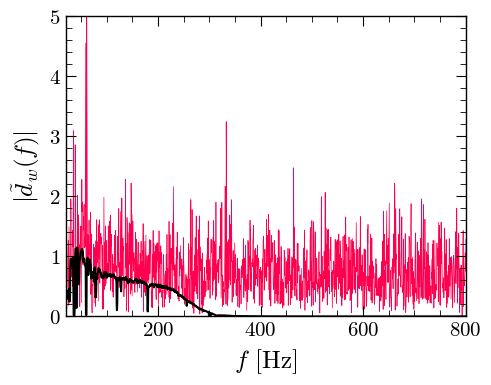

In [ ]:
fig2, secax = pf.create_plot()

secax.set_xlabel(r'$f$ [Hz]')
secax.set_ylabel(r'$|\tilde{d}_w(f)|$')
secax.set_xlim([20,800])
secax.set_ylim([0,5])


secax.plot(f,mu, color='k')
pf.fix_plot([secax])

True

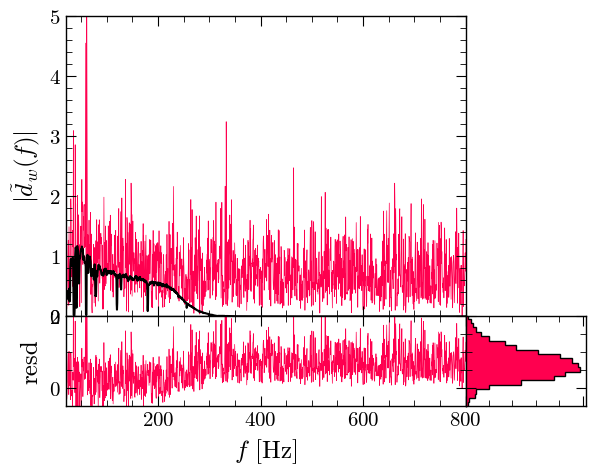

In [114]:
noise = gw.get_noise_fd(4)[0]
theta = gw._fd_theta_batched(4)
mu = gw._fd_waveform_batched(theta)[0]
f = gw.frequencies

fig, ax = pf.create_plot()
plt.setp(ax.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,.3), sharex=ax)
ax3 = fig.add_axes((1,-.3,.3,.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
axes = [ax,ax2,ax3]


gw150914 = gw.get_GW150914_fd()
ax.plot(f, gw150914, lw=0.5, color='#ff004f')
ax.plot(f,mu, color='k')

noise = gw150914-mu
ax2.plot(f, noise, color='#ff004f', lw=0.5)

ax3.hist(noise,bins=np.linspace(-1,5,50), histtype='step', orientation='horizontal', density=True, color='k')
ax3.hist(noise,bins=np.linspace(-1,5,50), orientation='horizontal', density=True, color='#ff004f')

ax2.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$|\tilde{d}_w(f)|$')
ax.set_xlim([20,800])
ax.set_ylim([0,5])
ax2.set_ylim([-.5,2])

ax2.set_ylabel('resd')

pf.fix_plot(axes)